In [1]:
version1 = 2
# or 3

In [2]:
import sopy as sp
import pandas as pd
import sopy.tensorly as stl
import tensorflow as tf
import itertools

import numpy as np
import matplotlib.pyplot as plt
from sopy.pyscf.ext import *

In [3]:
import numpy as np
from scipy.special import expi
import matplotlib.pyplot as plt
def calculate_psi(lattice, p, y):
    """
    Computes the value of the provided Mathematica expression.
    
    Parameters:
    L, d, p, y : float or complex
        Input variables corresponding to the Mathematica formula.
        
    Returns:
    complex
        The result of the calculation.
    """
    d = (lattice[1]-lattice[0])
    L = lattice[-1]-lattice[0]+d

    # Constants
    # In Python, '1j' is the imaginary unit (equivalent to Mathematica's 'I')
    I = 1j 
    Pi = np.pi
    
    # ---------------------------------------------------------
    # 1. Translate the Prefactor
    # Mathematica: -(1/(2 Sqrt[L] \[Pi])) I Sqrt[d] (E^(-I p y))
    # ---------------------------------------------------------
    
    # Calculate square roots once for clarity
    sqrt_L = np.sqrt(L)
    sqrt_d = np.sqrt(d)
    
    # Note: parentheses in the denominator (2 * sqrt_L * Pi) are crucial
    term_prefactor = -(1 / (2 * sqrt_L * Pi)) * I * sqrt_d * np.exp(-I * p * y)

    # ---------------------------------------------------------
    # 2. Translate the ExpIntegralEi terms
    # ---------------------------------------------------------
    
    # Term A: ExpIntegralEi[(I (-d p + \[Pi]) (L - 2 y))/(2 d)]
    arg_a = (I * (-d * p + Pi) * (L - 2 * y)) / (2 * d)
    term_a = expi(arg_a)
    
    # Term B: ExpIntegralEi[(I (d p + \[Pi]) (-(L/2) + y))/d]
    arg_b = (I * (d * p + Pi) * (-(L / 2) + y)) / d
    term_b = expi(arg_b)
    
    # Term C: ExpIntegralEi[(I (d p - \[Pi]) (L + 2 y))/(2 d)]
    arg_c = (I * (d * p - Pi) * (L + 2 * y)) / (2 * d)
    term_c = expi(arg_c)
    
    # Term D: ExpIntegralEi[(I (d p + \[Pi]) (L + 2 y))/(2 d)]
    arg_d = (I * (d * p + Pi) * (L + 2 * y)) / (2 * d)
    term_d = expi(arg_d)
    
    # ---------------------------------------------------------
    # 3. Combine them
    # Mathematica: (TermA - TermB - TermC + TermD)
    # ---------------------------------------------------------
    
    # 1. Construct the array with signs applied
    terms = ([term_a, -term_b, -term_c, term_d])
    
    # 2. Multiply by prefactor and replace any NaNs with 0.0
    # This is much faster and cleaner than list(map(...))
    result = term_prefactor *np.nan_to_num( terms, nan=0.0,posinf=0.0, 
    neginf=0.0)    
    return result

def def_crystal(lattice):
    d = lattice[1]-lattice[0]
    L = (lattice[-1]-lattice[0]+d)
    dp = 2.*np.pi/ L
    N  = len(lattice)
    N12 = N//2 # -0.5 removed to line up with FFT grid
    return [ dp*(n -N12) for n in range(N) ]

def ft_matrix(crystal,  lattice ):
    ft = np.transpose([[ calculate_psi(lattice, p , y) for p in crystal ] for y in lattice],(2,0,1))
    norm = 1./np.sqrt(np.mean( np.diag( np.dot(np.conj(np.transpose( sum(ft))), sum(ft)) ) ) ) 
    return norm * ft



In [4]:
DownSampling = 1
partition = 4
tol = 1e-12
# Vector
sampling_rate = 4
# spatial setup
if version1 == 2:
    padding = 5 #_2
elif version1 == 3:
    padding = 3 #_3
# compute extra
padding_factor = 1


atom_geometry = ''' H -1 1 0; H 1 -1 0;  '''
#atom_geometry = ''' I 1.4 0 0 ; I -1.4 0 0 ; I  0  0 1; I 0 0 -1'''
z_offset = 0.0


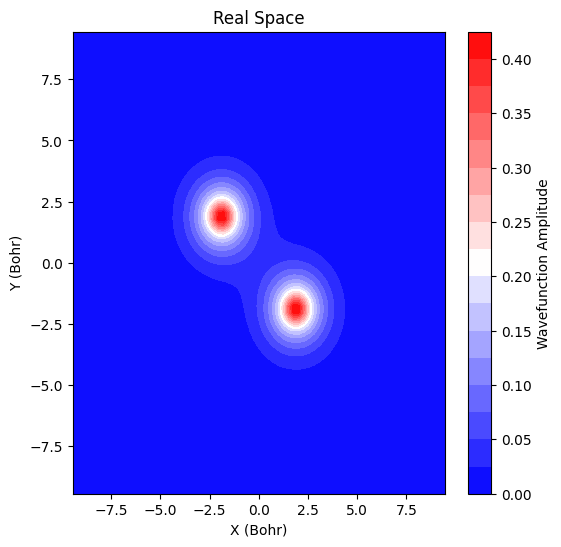

(75, 75)

In [5]:


from pyscf import gto, scf

def get_molecular_orbital_image(atom_str, basis, padding=3.0, sampling_rate=sampling_rate, canons = 4, z_offset = 0.0):
    """
    Calculates the HOMO orbital and slices it into a 2D image.
    """
    # 1. Build Molecule & Run SCF
    mol = gto.M(atom=atom_str, basis=basis, verbose=0)
    mf = scf.RHF(mol).run()
    
    # 2. Define the 2D Grid (Slice at Z=0)
    # We define a square window around the molecule
    L = np.max(np.abs(mol.atom_coords()))* padding
    grid_points = int( sampling_rate * 2 *L )
    x = np.linspace(-L, L, grid_points )
    y = np.linspace(-L, L, grid_points )
    X, Y = np.meshgrid(x, y)
    
    coords = np.vstack([X.flatten(), Y.flatten(), np.full_like(X.flatten(), z_offset)]).T

    # 3. Evaluate Orbitals on Grid
    # 'GTOval' calculates the value of the Atomic Orbitals (AO) at these points
    ao_value = mol.eval_gto("GTOval", coords)
    
    # Transform AO to Molecular Orbitals (MO) using the calculated coefficients
    # shape: (num_points, num_orbitals)
    mo_value = ao_value @ mf.mo_coeff
    
    # 4. Extract HOMO (Highest Occupied Molecular Orbital)
    # For a neutral closed shell, HOMO is at index n_elec/2 - 1
    n_occ = mol.nelectron // 2
    homo_idx = n_occ - 1
    homo_flat = mo_value[:, homo_idx]
    lattices = (x,y,x)

    # Reshape back to 2D image
    orbital_image = homo_flat.reshape(grid_points, grid_points)

    return grid_points, np.array([x, y]), X, Y, orbital_image

# --- Run the Generator ---

grid_points, lattices, X, Y, signal = get_molecular_orbital_image(atom_geometry, 'sto-3g', padding=padding, sampling_rate=sampling_rate, z_offset = z_offset)

# --- Visualize Input ---
plt.figure(figsize=(6, 6))
plt.contourf(X, Y, signal, levels=20, cmap='bwr') # bwr = Blue-White-Red (standard for orbitals)
plt.title("Real Space")
plt.xlabel("X (Bohr)")
plt.ylabel("Y (Bohr)")
plt.colorbar(label="Wavefunction Amplitude")
plt.show()
np.shape(signal)

In [6]:
use_tensorly = True


In [7]:
lattices = [ lattice[::DownSampling] for lattice in lattices ] 
domains = [ ( float(min(lattice)), float(max(lattice)) ) for lattice in lattices ]
dict_lattices = { d+1 : lattice for d,lattice in enumerate(lattices) }
dict_signal = {1:[signal[::DownSampling]], 0:tf.convert_to_tensor([[1.]],tf.float64)}
crystals = [ np.array(def_crystal( lattice ) ) for lattice in lattices ]
if use_tensorly:
    s = stl.reduce(signal[::DownSampling,::DownSampling], partition=partition)
    sopy_signal = sp.Operand( sp.Vector().transpose( s, dict_lattices).balance(threshold=tol), sp.Vector() )
else:
    sopy_signal = sp.Operand(generate_signal, sp.Vector())

fts = [ ft_matrix( crystal, lattice ) for crystal, lattice in zip(crystals, lattices) ]
#fts # ( canon, space, .. ) 
# all
tss = [ { d+1 : ts[d] for d in range(len(lattices)) } for ts in (list(itertools.product(*fts))) ]
# pairs
#tss = [ { d+1 : ts[d] for d in range(len(lattices)) } for ts in (np.transpose(fts,(1,0,2,3))) ]

#tss = [ {1:fts[0][0], 2:fts[1][4]},{1:fts[0][4], 2:fts[1][0]} ]#, {1:fts[0][2], 2:fts[1][3]} ]

volume = np.prod( [ (crystal[1]-crystal[0]) for crystal in crystals ] ) 

In [8]:
#len(tss)
np.shape(fts)


(2, 4, 75, 75)

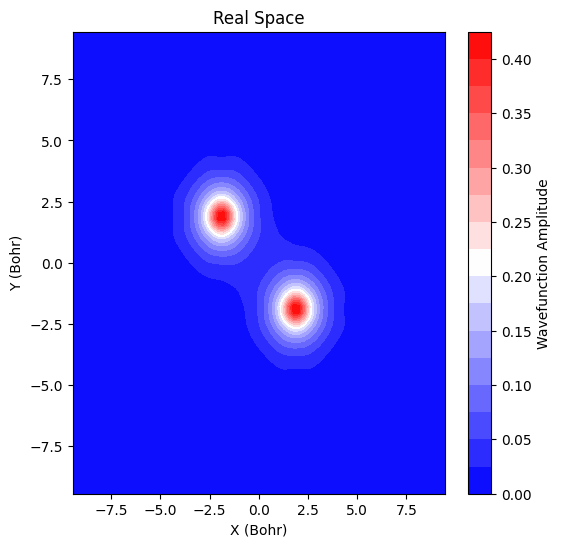

In [9]:
plt.figure(figsize=(6, 6))
plt.contourf(lattices[0], lattices[1], stl.image(sopy_signal.re), levels=20, cmap='bwr') # bwr = Blue-White-Red (standard for orbitals)
plt.title("Real Space")
plt.xlabel("X (Bohr)")
plt.ylabel("Y (Bohr)")
plt.colorbar(label="Wavefunction Amplitude")
plt.show()

In [10]:
def compute_fft(signal, sampling_rate, padding_factor=4):
    """
    Computes the 2D FFT magnitude with zero-padding and centering.
    """
    Ny, Nx = signal.shape
    Ny_padded = Ny * padding_factor
    Nx_padded = Nx * padding_factor
    
    # 1. Compute the 2D FFT with padding
    # 's' specifies the shape of the result (padding happens automatically)
    fft_complex = np.fft.fft2(signal, s=(Ny_padded, Nx_padded))
    
    # 2. Shift the zero-frequency component to the center of the spectrum
    # In 2D, we rarely slice "positive only" because we want to see symmetry/orientation.
    fft_shifted = np.fft.fftshift(fft_complex)
    
    # 3. Compute Magnitude and Normalize
    # Divide by the total number of ORIGINAL pixels (Ny * Nx) to preserve amplitude
    fft_magnitude = np.abs(fft_shifted) / (Ny * Nx)
    
    # 4. Compute Frequency Axes
    # We generate axes for both X and Y directions
    fx = np.fft.fftfreq(Nx_padded, 1/sampling_rate)
    fy = np.fft.fftfreq(Ny_padded, 1/sampling_rate)
    
    # Shift the frequency axes to match the shifted FFT
    fx = np.fft.fftshift(fx)
    fy = np.fft.fftshift(fy)
    
    # Create 2D coordinate grids for plotting
    FX, FY = np.meshgrid(fx, fy)
    
    return FX, FY, fft_magnitude




    
def trial_sopy(crystals, lattices, tss, s):
    """
    Computes the FFT magnitude and corresponding frequency axis.
    """

    #tss # ( canon, space , .. )
    norm = tf.sqrt(s.re.n()**2+ s.im.n()**2)
    dict_crystals = { d+1: crystal  for d,crystal in enumerate(crystals)}
    ss = s.exp_i([2*np.pi,0])
    #ss = sp.Operand(ss.re
    #   # .fibonacci(16, iterate =10)
    #                , ss.im#.im.fibonacci(16,iterate=10)
    #               )
    t = ss.transform( dict_crystals,  tss )
    return np.array(crystals), norm, t



# --- Main Execution ---

# 1. Bootup: Define parameters and create signal

import time

start_time = time.time()

# --- Your Code Here ---
for _ in range(1):
    freq_axis1, freq_axis2, fft_mag = compute_fft(signal, sampling_rate, padding_factor=padding_factor)
# ----------------------

end_time = time.time()
print(f"Execution time: {end_time - start_time:.4f} seconds")


start_time = time.time()

# --- Your Code Here ---
for _ in range(1):
    (wavenumber_axis1, wavenumber_axis2), norm, cft_mag = trial_sopy(crystals, lattices,  tss, sopy_signal)
# ----------------------

end_time = time.time()
print(f"Execution time: {end_time - start_time:.4f} seconds")




Execution time: 0.0026 seconds
Execution time: 9.2877 seconds


In [11]:
def wave(k_x, k_y):
    s=  (sopy_signal.exp_i([k_x, k_y]))
    return np.abs( s.trace( lattices ) )

#ft_mag = np.abs([[  wave(k_x,k_y) for k_x in wavenumber_axis1[20:70] ] for k_y in wavenumber_axis2[20:70]])


/var/folders/11/538cg1ns5pz87kzznt37_p0c0000gr/T/ipykernel_12642/2118299410.py:10: UserWarning: The following kwargs were not used by contour: 'color'
  ax1.contour(freq_axis1, freq_axis2,  fft_mag, color='blue')
/var/folders/11/538cg1ns5pz87kzznt37_p0c0000gr/T/ipykernel_12642/2118299410.py:28: UserWarning: The following kwargs were not used by contour: 'color'
  ax3.contour(wavenumber_axis1/(2*np.pi), wavenumber_axis2/(2*np.pi), cft_image, color='crimson')


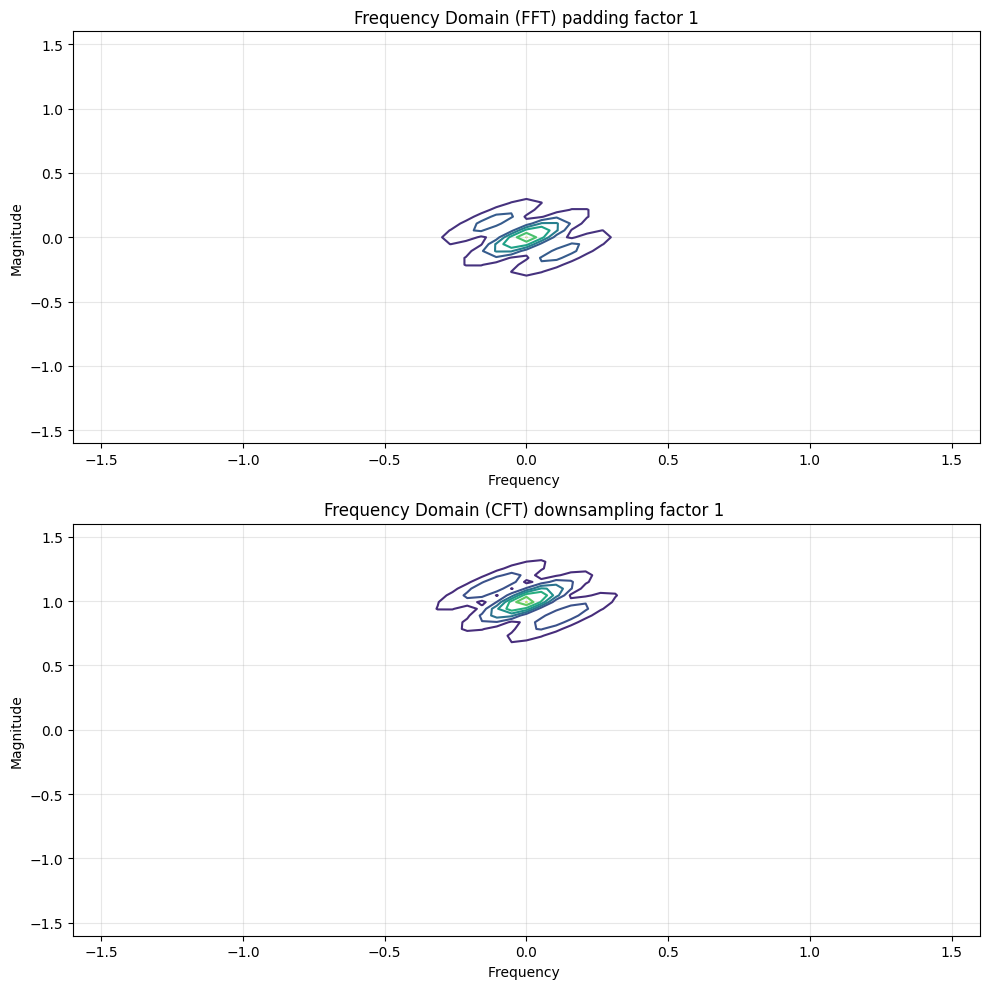

In [13]:
half_n_padded = len(crystals[0])//2

cft_image = tf.abs(stl.image(cft_mag.re) + 1.j * stl.image(cft_mag.im))#*2 *norm * volume/np.sqrt(len(crystals[0]))
#cft_image = tf.abs(stl.image(cft_mag.re) )*2 *norm * volume/np.sqrt(len(crystals[0]))

fig,  (ax1, ax3) = plt.subplots(2, 1, figsize=(10, 10))
plt.subplots_adjust(hspace=0.5) # Add breathing room between plots

# Plot Frequency Domain
ax1.contour(freq_axis1, freq_axis2,  fft_mag, color='blue')
ax1.set_title(f"Frequency Domain (FFT) padding factor {padding_factor}")
ax1.set_xlabel("Frequency ")
ax1.set_ylabel("Magnitude")
ax1.set(xlim=(-1.60, 1.60), ylim=(-1.60, 1.60))
ax1.grid(True, alpha=0.3)


# # Plot Frequency Domain
# ax2.contour(wavenumber_axis1[20:70]/(2*np.pi), wavenumber_axis1[20:70]/(2*np.pi),  ft_mag, color='blue')
# ax2.set_title(f"Frequency Domain (FT)")
# ax2.set_xlabel("Frequency ")
# ax2.set_ylabel("Magnitude")
# ax2.set(xlim=(-1.60, 1.60), ylim=(-1.60, 1.60))

# ax2.grid(True, alpha=0.3)

# Plot Frequency Domain
ax3.contour(wavenumber_axis1/(2*np.pi), wavenumber_axis2/(2*np.pi), cft_image, color='crimson')
ax3.set_title(f"Frequency Domain (CFT) downsampling factor {DownSampling} ")
ax3.set_xlabel("Frequency ")
ax3.set_ylabel("Magnitude")
ax3.grid(True, alpha=0.3)
ax3.set(xlim=(-1.60, 1.60), ylim=(-1.60, 1.60))

plt.tight_layout()
plt.show()

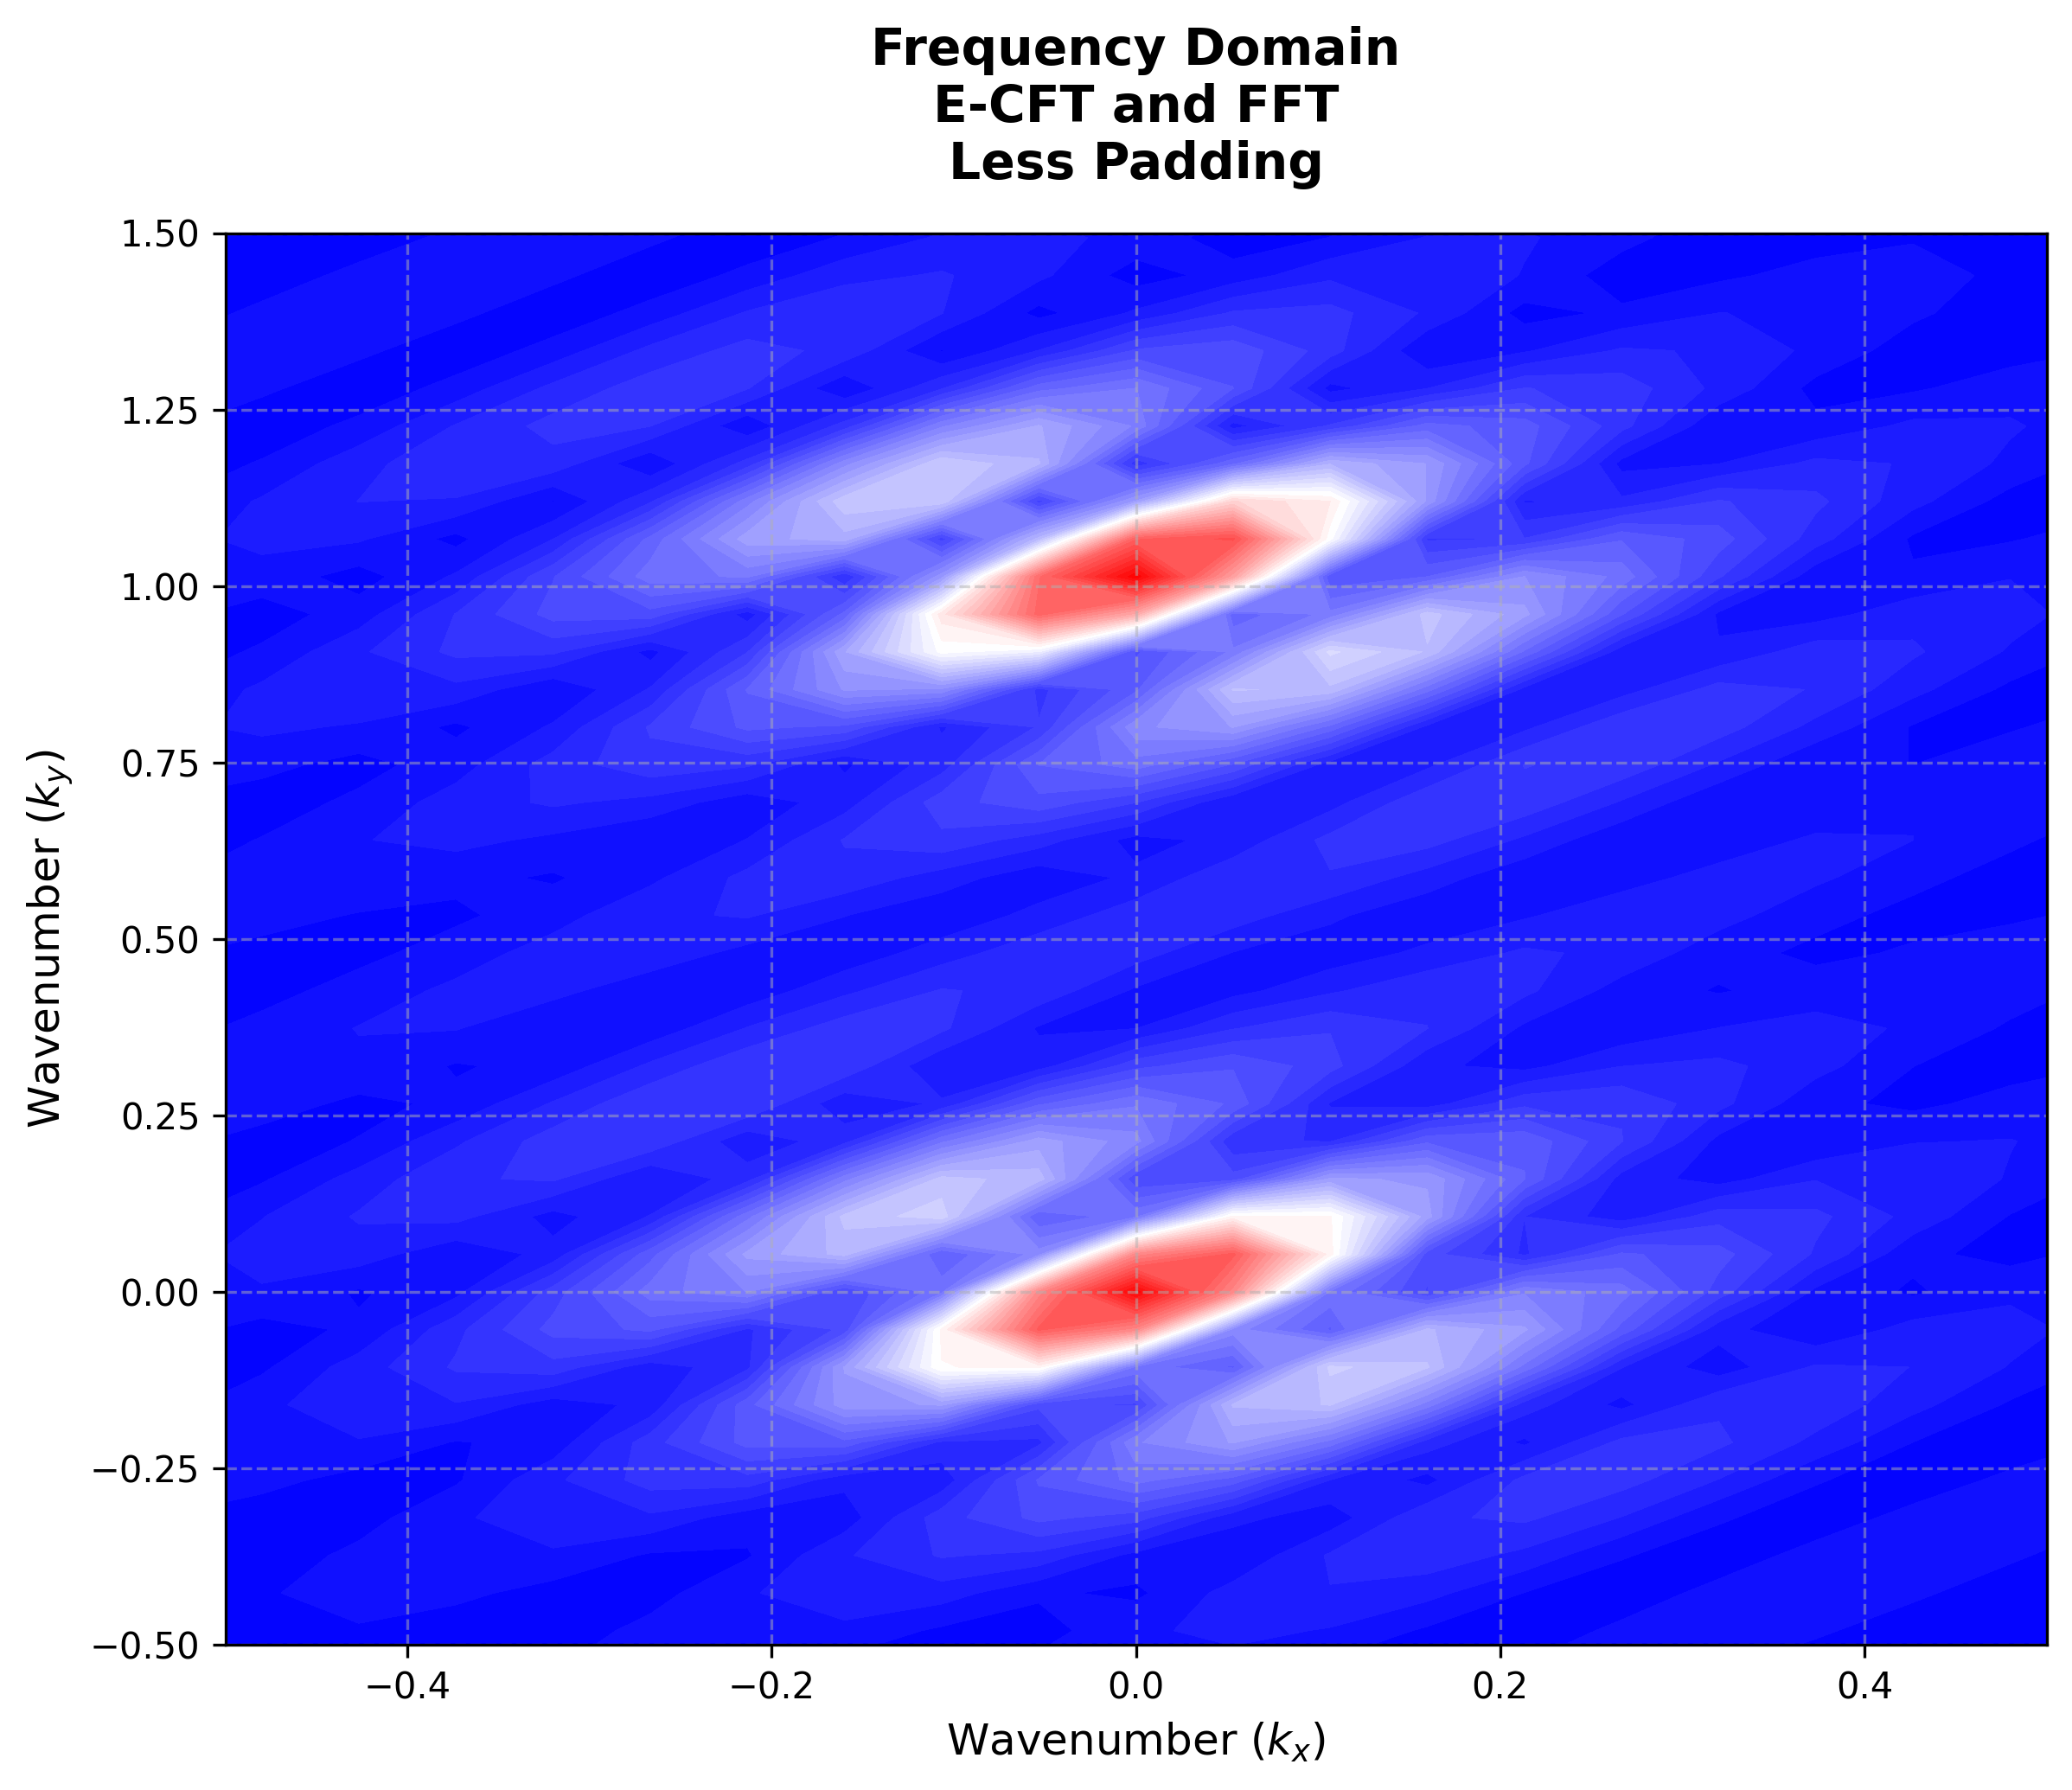

In [14]:
import matplotlib.pyplot as plt

# Set a professional style
plt.figure(figsize=(8, 7), dpi=300)

# Use contourf for filled regions; often looks better for FFT magnitude
# Increase levels for smoother transitions
contour = plt.contourf(freq_axis1, freq_axis2, fft_mag/np.sum( fft_mag)+cft_image/np.sum(cft_image), levels=50, cmap='bwr')

# Add a colorbar to make the plot quantitative
#cbar = plt.colorbar(contour)
#cbar.set_label('Magnitude (dB or Linear Scale)', rotation=270, labelpad=15)

# Fix: Use set_xlim/ylim or plt.axis() instead of tuple assignments

# Labels and Title
plt.title(f"Frequency Domain\nE-CFT and FFT\nLess Padding", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Wavenumber ($k_x$)", fontsize=12)
plt.ylabel("Wavenumber ($k_y$)", fontsize=12)
# Grid and Layout
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,1.5)
# Export to High-Resolution JPEG
plt.savefig(f"FT_Analysis_Report_{version1}_.jpg", format='jpg', dpi=300)

plt.show()
